# Natural Language Processing Pipeline and Text Classification

**Course:** AI Programming  
**Assignment:** NLP Pipeline and Text Classification  
**Dataset:** NLP Dataset 9 - Real Estate Inquiry Category  

## Business Problem

A real estate company receives many customer inquiries from different channels, such as email, chat, website forms, phone transcripts, and open house cards. These messages are about different topics, including price questions, rental applications, mortgage information, viewing requests, maintenance concerns, and neighbourhood questions.

If staff members have to read and sort every inquiry manually, responses can become slow and some important leads may be delayed. The purpose of this project is to build a basic NLP text classification model that can automatically predict the inquiry category from the customer message. This can help the business route each inquiry to the right team faster, improve customer service, and support better lead management.

## Task 1: Load and Inspect the Dataset

In this section, the dataset is loaded and inspected to understand its size, columns, missing values, and target variable distribution.

In [1]:
# Import main libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import string
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Display settings
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_columns', 20)

In [2]:
# Load the dataset
file_path = "NLP_Dataset_9_Real_Estate_Inquiry_Category.xlsx"
df = pd.read_excel(file_path)

# Inspect dataset shape and first rows
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

df.head()

Dataset shape: (120, 9)

Column names:
['InquiryID', 'InquiryDate', 'Channel', 'City', 'PropertyType', 'ClientType', 'InquiryText', 'InquiryCategory', 'LeadScore']


,InquiryID,InquiryDate,Channel,City,PropertyType,ClientType,InquiryText,InquiryCategory,LeadScore
0,REA-001,2026-03-23,Email,Ajax,Commercial Unit,Investor,"Is the listed price negotiable, or is the seller firm at $725,000?",Price_Question,9
1,REA-002,2026-03-26,Phone Transcript,Toronto,Condo,Renter,My landlord reference is available after Friday. Can I still apply today?,Rental_Application,18
2,REA-003,2026-03-29,Chat,Burlington,Duplex,Family,Can you connect me with a mortgage advisor before I make an offer?,Mortgage_Info,27
3,REA-004,2026-04-01,Open House Card,Burlington,Commercial Unit,Small Business Owner,I want to know if MapleKey Realty expects a price change next week. #MapleKey,Price_Question,36
4,REA-005,2026-04-04,Website Form,Markham,Duplex,First-Time Buyer,Can MapleKey Realty show me the townhouse after 5 PM on June 14?,Viewing_Request,45


In [3]:
# Check data types, missing values, duplicates, and target distribution
print("Data types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget variable distribution:")
print(df['InquiryCategory'].value_counts())

Data types:
InquiryID                  object
InquiryDate        datetime64[ns]
Channel                    object
City                       object
PropertyType               object
ClientType                 object
InquiryText                object
InquiryCategory            object
LeadScore                   int64
dtype: object

Missing values:
InquiryID          0
InquiryDate        0
Channel            0
City               0
PropertyType       0
ClientType         0
InquiryText        0
InquiryCategory    0
LeadScore          0
dtype: int64

Duplicate rows: 0

Target variable distribution:
InquiryCategory
Price_Question         20
Rental_Application     20
Mortgage_Info          20
Viewing_Request        20
Maintenance_Concern    20
Neighbourhood          20
Name: count, dtype: int64


### Column Explanation

- **InquiryID:** Unique ID for each customer inquiry.
- **InquiryDate:** Date when the inquiry was received.
- **Channel:** The source of the inquiry, such as email, chat, website form, or phone transcript.
- **City:** The city related to the inquiry.
- **PropertyType:** The type of property mentioned, such as condo, townhouse, duplex, or commercial unit.
- **ClientType:** The type of customer, such as renter, investor, family, or first-time buyer.
- **InquiryText:** The main customer message. This is the text column used for NLP.
- **InquiryCategory:** The target variable that the model will predict.
- **LeadScore:** A score that may represent the business value or priority of the lead.

The dataset contains 120 records and 9 columns. The target variable is balanced because each inquiry category has 20 records. This is helpful because the model receives an equal number of examples from each class.

## Task 2: Text Preprocessing

Text data cannot be used directly by most machine learning models. It must first be cleaned and standardized. In this section, the text is converted to lowercase, punctuation is removed, stopwords are removed, the text is tokenized, and a simple lemmatization style cleaning step is applied.

In [6]:
# Choose the main text column and target column
text_column = 'InquiryText'
target_column = 'InquiryCategory'

# Simple lemmatization-style helper for this assignment
def simple_lemma(word):
    """A small rule-based lemmatization helper used to avoid external downloads."""
    if len(word) > 4 and word.endswith('ies'):
        return word[:-3] + 'y'
    if len(word) > 5 and word.endswith('ing'):
        return word[:-3]
    if len(word) > 4 and word.endswith('ed'):
        return word[:-2]
    if len(word) > 3 and word.endswith('s'):
        return word[:-1]
    return word

def preprocess_text(text):
    # Convert to string and lowercase
    text = str(text).lower()
    
    # Remove hashtags but keep the word after the hashtag
    text = text.replace('#', ' ')
    
    # Remove punctuation and numbers that do not help category prediction
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # Tokenize by splitting on spaces
    tokens = text.split()
    
    # Remove stopwords and very short tokens
    tokens = [word for word in tokens if word not in ENGLISH_STOP_WORDS and len(word) > 2]
    
    # Apply simple lemmatization-style normalization
    tokens = [simple_lemma(word) for word in tokens]
    
    # Join tokens back into one cleaned text string
    return ' '.join(tokens)

# Apply preprocessing
df['CleanedText'] = df[text_column].apply(preprocess_text)

# Compare original and cleaned text
df[[text_column, 'CleanedText']].head(10)

,InquiryText,CleanedText
0,"Is the listed price negotiable, or is the seller firm at $725,000?",list price negotiable seller firm
1,My landlord reference is available after Friday. Can I still apply today?,landlord reference available friday apply today
2,Can you connect me with a mortgage advisor before I make an offer?,connect mortgage advisor make offer
3,I want to know if MapleKey Realty expects a price change next week. #MapleKey,want know maplekey realty expect price change week maplekey
4,Can MapleKey Realty show me the townhouse after 5 PM on June 14?,maplekey realty townhouse june
5,The basement photo shows water marks. Has the owner repaired the leak?,basement photo show water mark owner repair leak
6,"My bank approved me for $640,000, but I am not sure about closing costs. #MapleKey",bank approv sure clos cost maplekey
7,Please schedule a virtual tour because I am currently outside Oshawa.,schedule virtual tour currently outside oshawa
8,The elevator in the condo building was out of service when I visited on Monday.,elevator condo build service visit monday
9,Is the area near the station safe at night? I do not know this part of town.,area near station safe night know town


### Preprocessing Interpretation

The original messages contain capital letters, punctuation, dates, dollar amounts, and common words such as "the", "is", "can", and "me". After preprocessing, the text becomes shorter and more focused on useful words. For example, a message about a mortgage advisor keeps words such as **mortgage**, **advisor**, **make**, and **offer**.

This step is important because it reduces noise and helps the model focus on the words that are most useful for predicting the inquiry category.

## Task 3: Exploratory Text Analysis

This section looks at the most common words in the cleaned inquiry text. This helps reveal the main topics customers are asking about.

In [7]:
# Create word frequency counts from cleaned text
all_words = ' '.join(df['CleanedText']).split()
word_counts = Counter(all_words)

# Convert to dataframe
common_words = pd.DataFrame(word_counts.most_common(20), columns=['Word', 'Frequency'])
common_words

,Word,Frequency
0,maplekey,33
1,price,20
2,want,15
3,view,15
4,need,15
5,list,10
6,mortgage,10
7,know,10
8,realty,10
9,june,10


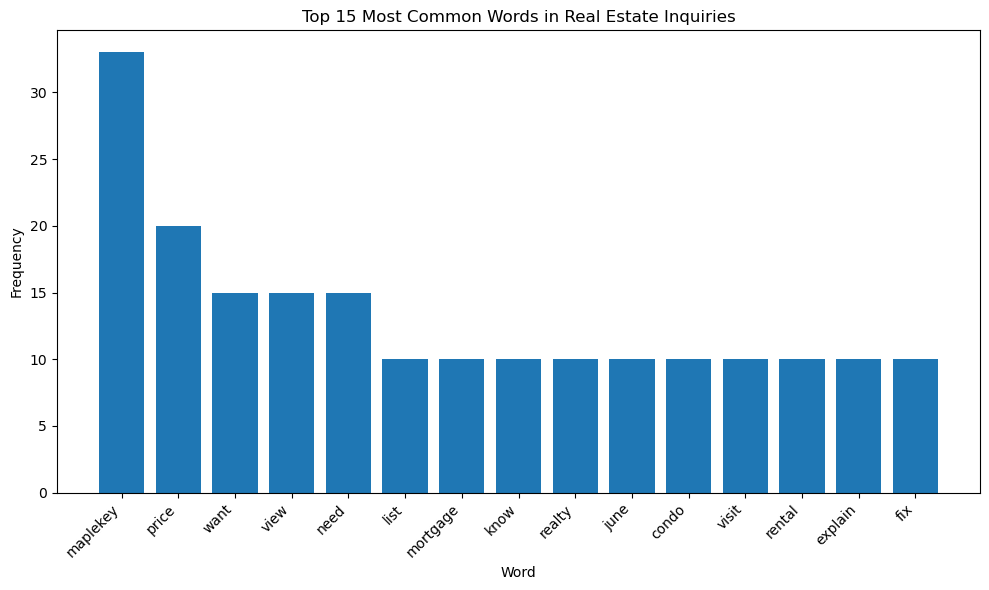

In [8]:
# Bar chart of top 15 frequent words
top_words = common_words.head(15)

plt.figure(figsize=(10, 6))
plt.bar(top_words['Word'], top_words['Frequency'])
plt.title('Top 15 Most Common Words in Real Estate Inquiries')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Exploratory Text Analysis Interpretation

The most frequent words show that many inquiries are related to real estate services, property information, viewing requests, pricing, rentals, mortgage questions, maintenance issues, and neighbourhood details.

From a business perspective, this is useful because it shows the company what customers ask about most often. If words related to viewing, mortgage, price, and rental applications appear frequently, the company can prepare faster response templates and assign staff to the most common inquiry types.

## Task 4: POS Tagging and Named Entity Recognition

Part-of-speech tagging helps identify whether words are nouns, verbs, adjectives, or other word types. Named Entity Recognition helps detect names, organizations, locations, dates, and other important entities.

The code below first tries to use spaCy if it is available. If spaCy is not installed, it uses a simple rule-based fallback so the notebook can still run successfully.

In [9]:
# Select three example records
examples = df[text_column].head(3).tolist()
examples

['Is the listed price negotiable, or is the seller firm at $725,000?',
 'My landlord reference is available after Friday. Can I still apply today?',
 'Can you connect me with a mortgage advisor before I make an offer?']

In [10]:
# POS tagging and NER with spaCy if available, otherwise a simple rule-based fallback

def rule_based_pos(word):
    lower = word.lower().strip(string.punctuation)
    if lower in {'is', 'are', 'am', 'be', 'can', 'show', 'connect', 'make', 'apply', 'want', 'know', 'expect'} or lower.endswith('ing'):
        return 'VERB'
    if lower.endswith(('able', 'ive', 'al', 'ous', 'ful')):
        return 'ADJECTIVE'
    if word[:1].isupper():
        return 'PROPER_NOUN'
    return 'NOUN'

def simple_ner(text):
    entities = []
    # Organizations / brand-like names
    if 'MapleKey Realty' in text:
        entities.append(('MapleKey Realty', 'ORGANIZATION'))
    # Dates
    date_matches = re.findall(r'\b(?:January|February|March|April|May|June|July|August|September|October|November|December)\s+\d{1,2}\b', text)
    for match in date_matches:
        entities.append((match, 'DATE'))
    # Money
    money_matches = re.findall(r'\$[0-9,]+', text)
    for match in money_matches:
        entities.append((match, 'MONEY'))
    return entities

try:
    import spacy
    nlp = spacy.load('en_core_web_sm')
    use_spacy = True
except Exception:
    use_spacy = False

for i, text in enumerate(examples, start=1):
    print(f"\nExample {i}: {text}")
    print('-' * 80)
    
    if use_spacy:
        doc = nlp(text)
        print('POS Tags:')
        for token in doc:
            if not token.is_punct and not token.is_space:
                print(f"{token.text:20s} {token.pos_}")
        print('\nNamed Entities:')
        if doc.ents:
            for ent in doc.ents:
                print(f"{ent.text:25s} {ent.label_}")
        else:
            print('No named entities detected.')
    else:
        words = [w.strip() for w in text.split() if w.strip()]
        print('POS Tags using rule-based fallback:')
        for word in words:
            clean_word = word.strip(string.punctuation)
            if clean_word:
                print(f"{clean_word:20s} {rule_based_pos(clean_word)}")
        print('\nNamed Entities using rule-based fallback:')
        ents = simple_ner(text)
        if ents:
            for ent, label in ents:
                print(f"{ent:25s} {label}")
        else:
            print('No named entities detected by fallback rules.')


Example 1: Is the listed price negotiable, or is the seller firm at $725,000?
--------------------------------------------------------------------------------
POS Tags using rule-based fallback:
Is                   VERB
the                  NOUN
listed               NOUN
price                NOUN
negotiable           ADJECTIVE
or                   NOUN
is                   VERB
the                  NOUN
seller               NOUN
firm                 NOUN
at                   NOUN
725,000              NOUN

Named Entities using rule-based fallback:
$725,000                  MONEY

Example 2: My landlord reference is available after Friday. Can I still apply today?
--------------------------------------------------------------------------------
POS Tags using rule-based fallback:
My                   PROPER_NOUN
landlord             NOUN
reference            NOUN
is                   VERB
available            ADJECTIVE
after                NOUN
Friday               PROPER_NOUN
Can     

### POS and NER Interpretation

The POS tags help identify the role of words in the message. Nouns usually represent important business objects, such as **price**, **seller**, **landlord**, **reference**, **mortgage**, **advisor**, and **offer**. Verbs show customer actions, such as **apply**, **connect**, **make**, or **show**. Adjectives can describe conditions or qualities.

Named entities are also useful in business text analysis. For example, an organization name such as **MapleKey Realty**, a date such as **June 14**, or a money amount such as **$725,000** can help the business understand which company, time, or financial detail is involved in the inquiry.

## Task 5: Feature Extraction

Machine learning models cannot understand raw text directly. The cleaned text must be converted into numerical features. In this notebook, TF-IDF is used because it gives more importance to words that are useful for distinguishing one inquiry from another.

In [11]:
# Define features and target
X_text = df['CleanedText']
y = df[target_column]

# Split data before vectorization to avoid data leakage
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.20, random_state=42, stratify=y)

# Convert text to numerical TF-IDF features
tfidf = TfidfVectorizer(max_features=500, ngram_range=(1, 2))
X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

print('Training feature matrix shape:', X_train.shape)
print('Testing feature matrix shape:', X_test.shape)

Training feature matrix shape: (96, 287)
Testing feature matrix shape: (24, 287)


### Feature Extraction Explanation

TF-IDF changes each cleaned inquiry into a row of numbers. These numbers represent how important each word or phrase is in the message. This is necessary because models such as Logistic Regression work with numerical inputs, not raw sentences.

## Task 6: Build a Text Classification Model

A Logistic Regression model is used for classification. This model is a strong choice for text classification because it works well with TF-IDF features, trains quickly, and is easier to interpret than many complex models.

In [12]:
# Train a Logistic Regression text classifier
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Show a few predictions
prediction_results = pd.DataFrame({
    'CleanedText': X_test_text.values,
    'ActualCategory': y_test.values,
    'PredictedCategory': y_pred})

prediction_results.head(10)

,CleanedText,ActualCategory,PredictedCategory
0,utility includ monthly price budget extra,Price_Question,Price_Question
1,landlord reference available friday apply today,Rental_Application,Rental_Application
2,rent look high compar similar apartment whitby explain price,Price_Question,Price_Question
3,maplekey realty townhouse june,Viewing_Request,Viewing_Request
4,want quiet neighbourhood work home children,Neighbourhood,Neighbourhood
5,responsible snow removal lawn care rental property,Maintenance_Concern,Maintenance_Concern
6,connect mortgage advisor make offer,Mortgage_Info,Mortgage_Info
7,elevator condo build service visit monday,Maintenance_Concern,Maintenance_Concern
8,area near station safe night know town,Neighbourhood,Neighbourhood
9,want know maplekey realty expect price change week,Price_Question,Price_Question


## Task 7: Model Evaluation

The model is evaluated using accuracy, a confusion matrix, and a classification report. These metrics show how well the model classifies customer inquiries into the correct business category.

In [13]:
# Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy percentage: {accuracy * 100:.2f}%")

Accuracy: 1.0000
Accuracy percentage: 100.00%


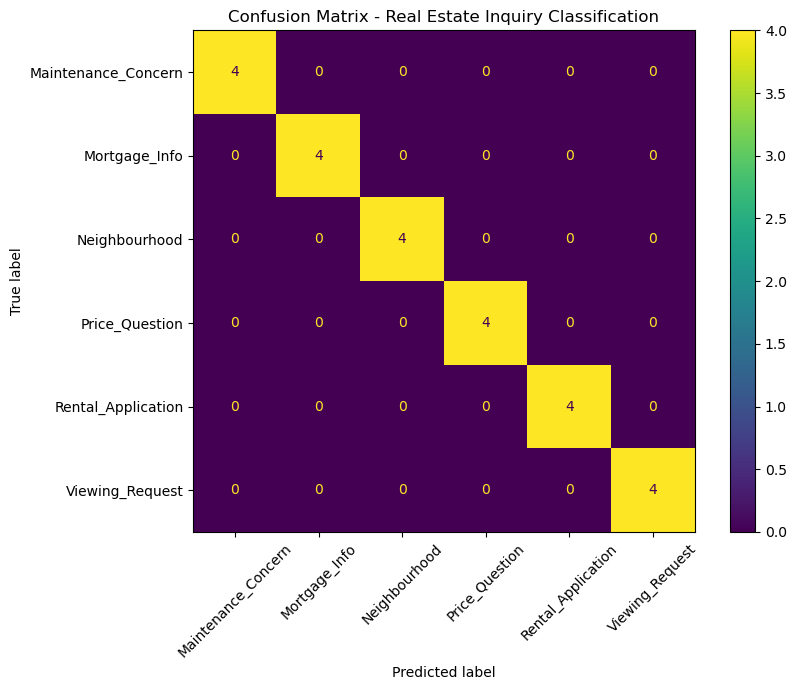

In [14]:
# Confusion matrix
labels = sorted(df[target_column].unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, xticks_rotation=45, values_format='d')
plt.title('Confusion Matrix - Real Estate Inquiry Classification')
plt.tight_layout()
plt.show()

In [15]:
# Classification report
print(classification_report(y_test, y_pred))

                     precision    recall  f1-score   support

Maintenance_Concern       1.00      1.00      1.00         4
      Mortgage_Info       1.00      1.00      1.00         4
      Neighbourhood       1.00      1.00      1.00         4
     Price_Question       1.00      1.00      1.00         4
 Rental_Application       1.00      1.00      1.00         4
    Viewing_Request       1.00      1.00      1.00         4

           accuracy                           1.00        24
          macro avg       1.00      1.00      1.00        24
       weighted avg       1.00      1.00      1.00        24



In [16]:
# Identify incorrect predictions, if any
errors = prediction_results[prediction_results['ActualCategory'] != prediction_results['PredictedCategory']]
print('Number of misclassified test records:', len(errors))
errors

Number of misclassified test records: 0


,CleanedText,ActualCategory,PredictedCategory


### Model Evaluation Interpretation in Business Language

Accuracy shows the percentage of customer inquiries that were assigned to the correct category. A high accuracy means the model is useful for automatically sorting inquiries and reducing manual work.

The confusion matrix shows where the model made correct predictions and where it made mistakes. The diagonal values represent correct classifications. Values outside the diagonal represent errors.

In business terms, mistakes matter because an inquiry may be sent to the wrong team. For example, if a viewing request is classified as a price question, the customer may not receive a quick appointment response. If a maintenance concern is classified as a general neighbourhood question, the issue may not be handled quickly. This is why model evaluation is important before using the model in a real business setting.

## Additional Model Interpretation: Important Words by Category

To make the model more understandable, the code below shows the words that strongly influence each predicted category.

In [17]:
# Show top words for each category based on Logistic Regression coefficients
feature_names = np.array(tfidf.get_feature_names_out())

for class_label, coefficients in zip(model.classes_, model.coef_):
    top_indices = coefficients.argsort()[-8:][::-1]
    top_terms = feature_names[top_indices]
    print(f"\nTop terms for {class_label}:")
    print(', '.join(top_terms))


Top terms for Maintenance_Concern:
said, view agent, window view, window, notic, notic broken, agent said, agent

Top terms for Mortgage_Info:
mortgage, requirement, payment requirement, time, need information, buyer, requirement time, time buyer

Top terms for Neighbourhood:
transit, work home, home children, quiet, work, neighbourhood work, want quiet, neighbourhood

Top terms for Price_Question:
price, seller, negotiable seller, list price, seller firm, negotiable, firm, price negotiable

Top terms for Rental_Application:
employment, employment letter, letter apartment, letter, report, report employment, credit, credit report

Top terms for Viewing_Request:
townhouse june, townhouse, realty townhouse, view, outside, tour, virtual tour, currently


### Important Word Interpretation

The important words help explain why the model makes certain predictions. For example, words related to **mortgage**, **advisor**, or **pre-approval** are likely to support the Mortgage_Info category. Words such as **viewing**, **show**, or **appointment** are more connected to Viewing_Request. This makes the model more transparent and easier for a business user to understand.

## Task 8: Final Business Interpretation

This project built a Natural Language Processing pipeline to classify real estate customer inquiries. The dataset used was the **Real Estate Inquiry Category** dataset, which contains customer messages from multiple communication channels. The selected text column was **InquiryText**, and the target variable was **InquiryCategory**.

The preprocessing steps included converting text to lowercase, removing punctuation, removing stopwords, tokenizing the text, applying simple lemmatization-style normalization, and creating a cleaned text column. TF-IDF was used to convert the cleaned text into numerical features. A Logistic Regression model was then trained to predict the inquiry category.

The model is useful because it can help a real estate company automatically route customer inquiries to the correct department. This can reduce manual sorting, improve response time, and help agents focus on the most important leads.

One business insight from the text analysis is that customers frequently ask about pricing, mortgage support, rental applications, viewings, neighbourhood information, and maintenance concerns. These topics show where the company should focus its customer service resources.

One limitation is that the dataset contains only 120 records. Although the categories are balanced, a larger dataset with more varied real-world messages would help the model learn more language patterns and perform better on new customer inquiries.